<a href="https://colab.research.google.com/github/smk00513/Analysis-of-Public-Parking-in-Busan/blob/main/Term_202355713_%EC%86%A1%EB%AA%85%EA%B7%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install requests xmltodict folium

# 부산광역시 공영주차장


부산광역시 공영주차장 위치

In [ ]:
import requests
import json

all_items = []

url = 'http://apis.data.go.kr/6260000/BusanPblcPrkngInfoService/getPblcPrkngInfo'
service_key = 'jxjdzg0uupNVAiS+WURvIDZ40GaHXO11YJLdbKtPLS9r8bO6eaA/XtWL3gmwbTQZhD+mm4qgg/GACpNnSVsBLw=='  # 실제키

for page in range(1, 11):  # 10페이지 수집 시도 (필요시 늘리기)
    params = {
        'serviceKey': service_key,
        'pageNo': str(page),
        'numOfRows': '100',
        'resultType': 'json'
    }
    response = requests.get(url, params=params)
    data = json.loads(response.content.decode('utf-8'))
    items = data['response']['body']['items']['item']
    all_items.extend(items)

print(f"총 수집 데이터 개수: {len(all_items)}")


총 수집 데이터 개수: 615


In [ ]:
# 첫 번째 주차장 정보 전체 출력 (예: 구조 확인용)
import pprint
pprint.pprint(all_items[0])

# 또는 여러 개를 보기
for i, item in enumerate(all_items[:5]):
    print(f"\n--- 주차장 {i+1} ---")
    pprint.pprint(item)


{'bujeGubun': '-',
 'currava': '-',
 'doroAddr': '-',
 'feeAdd': '0',
 'feeInfo': '-',
 'fnlDt': '08/24/2009',
 'ftDay': '0',
 'ftDayApplytime': '-',
 'ftMon': '0',
 'guNm': '부산광역시 사하구청',
 'hldEndTe': '-',
 'hldSrtTe': '-',
 'jibunAddr': '사하구 감천2동 13-1114',
 'ldRtg': '기타',
 'mgntNum': '2009000012',
 'oprDay': '-',
 'oprt_fm': None,
 'payMtd': '-',
 'pkAddTime': '10',
 'pkBascTime': '10',
 'pkCnt': '77',
 'pkFm': '노상',
 'pkGubun': '공영',
 'pkNam': '감천2동천마산산복도로',
 'satEndTe': '-',
 'satSrtTe': '-',
 'spclNote': '-',
 'svcEndTe': '-',
 'svcSrtTe': '-',
 'tenMin': '0',
 'tponNum': '-',
 'xCdnt': '35.093',
 'yCdnt': '129.011'}

--- 주차장 1 ---
{'bujeGubun': '-',
 'currava': '-',
 'doroAddr': '-',
 'feeAdd': '0',
 'feeInfo': '-',
 'fnlDt': '08/24/2009',
 'ftDay': '0',
 'ftDayApplytime': '-',
 'ftMon': '0',
 'guNm': '부산광역시 사하구청',
 'hldEndTe': '-',
 'hldSrtTe': '-',
 'jibunAddr': '사하구 감천2동 13-1114',
 'ldRtg': '기타',
 'mgntNum': '2009000012',
 'oprDay': '-',
 'oprt_fm': None,
 'payMtd': '-',
 'pkAd

In [ ]:
import folium

busan_map = folium.Map(location=[35.1796, 129.0756], zoom_start=12)

def safe_float(value):
    try:
        return float(value)
    except (TypeError, ValueError):
        return None  # 혹은 0, 원하는 기본값

for p in all_items:
    lat = safe_float(p.get('xCdnt'))
    lng = safe_float(p.get('yCdnt'))
    name = p.get('pkNam')
    if lat is not None and lng is not None:
        folium.CircleMarker(
            location=[lat, lng],
            radius=1,               # 원 크기
            color='blue',           # 테두리 색
            fill=True,
            fill_color='cyan',      # 채우기 색
            fill_opacity=0.7,
            popup=name
        ).add_to(busan_map)

busan_map

# 부산광역시 유동인구 수


In [ ]:
import pandas as pd
import folium
from folium.features import DivIcon

# 엑셀 파일 읽기 (xlsx 파일 경로를 본인의 경로로 바꾸세요)
df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/Data/셀단위데이터이용_50대관광지별_유동인구.xlsx', sheet_name = 3, header=1, engine='openpyxl')

# 필요한 열만 선택 (예: '구'와 '총합계' 열)
# 예: 공백 제거
df_selected = df[['구', '2021~2022년합계']]

# '구'별 합계 (만약 구별로 여러 행이 있으면)
df_sum = df_selected.groupby('구').sum().reset_index()

# 부산 각 구 위경도 좌표 (기존 딕셔너리 사용)
gu_location = {
    '중구': [35.1065, 129.0326],
    '서구': [35.0971, 129.0242],
    '동구': [35.1293, 129.0451],
    '영도구': [35.0916, 129.0680],
    '부산진구': [35.1629, 129.0535],
    '동래구': [35.2050, 129.0830],
    '남구': [35.1360, 129.0846],
    '북구': [35.1975, 128.9906],
    '해운대구': [35.1631, 129.1635],
    '사하구': [35.1044, 128.9741],
    '금정구': [35.2429, 129.0923],
    '강서구': [35.2122, 128.9803],
    '연제구': [35.1766, 129.0790],
    '수영구': [35.1459, 129.1134],
    '사상구': [35.1531, 128.9908],
    '기장군': [35.2444, 129.2228],
}

# 지도 생성
m = folium.Map(location=[35.1796, 129.0756], zoom_start=12)

# 원형 마커 + 텍스트 표시
for _, row in df_sum.iterrows():
    gu = row['구']
    total_population = row['2021~2022년합계']

    if gu in gu_location:
        lat, lon = gu_location[gu]

        # 동적 폰트 크기 설정 (최소 12, 최대 18)
        font_size = min(max(int(total_population / 300000), 12), 18)

        # 원형 마커 (연녹색으로 가독성 향상)
        folium.CircleMarker(
            location=[lat, lon],
            radius=total_population / 55000,
            color='#228B22',         # 진녹색 테두리
            fill=True,
            fill_color='#90ee90',    # 연녹색 내부
            fill_opacity=0.6,
            popup=f"{gu}: {total_population:,}명"
        ).add_to(m)

        # 텍스트 레이블
        folium.map.Marker(
            [lat, lon],
            icon=DivIcon(
                icon_size=(0, 0),
                icon_anchor=(10, 0),  # 아이콘 기준 위치
                html=f'''
                <div style="
                    font-size: {font_size}px;
                    font-weight: bold;
                    color: black;
                    text-align: center;
                    transform: translate(-50%, -50%);
                    border-radius: 8px;
                    padding: 2px 6px;
                    box-shadow: 1px 1px 4px rgba(0,0,0,0.4);">
                    {total_population:,}
                </div>''',
            )
        ).add_to(m)

def safe_float(value):
    try:
        return float(value)
    except (TypeError, ValueError):
        return None

for p in all_items:
    lat = safe_float(p.get('xCdnt'))
    lng = safe_float(p.get('yCdnt'))
    name = p.get('pkNam')
    if lat is not None and lng is not None:
        folium.CircleMarker(
            location=[lat, lng],
            radius=2,  # 주차장은 좀 더 크게 표시
            color='blue',
            fill=True,
            fill_color='cyan',
            fill_opacity=0.7,
            popup=name
        ).add_to(m)

# 지도 출력
m


In [ ]:
import re
from collections import Counter

# 시군구명 추출 함수 (주소에서 'XX구' 형태 찾기)
def extract_gu(address):
    if not address:
        return None
    match = re.search(r'(\w+(구|군))', address)
    if match:
        return match.group(1)
    return None

# 모든 주차장 주소에서 구 이름 추출
gu_list = [extract_gu(p.get('jibunAddr')) for p in all_items]

# None 제외 후 개수 세기
gu_list = [gu for gu in gu_list if gu]
parking_count = Counter(gu_list)

# 결과 예시 출력
print(parking_count)

Counter({'동구': 57, '부산진구': 44, '사하구': 42, '금정구': 40, '사상구': 31, '북구': 29, '서구': 28, '영도구': 24, '기장군': 23, '연제구': 22, '남구': 20, '동래구': 13, '수영구': 5, '중구': 3, '강서구': 2})


In [ ]:
import pandas as pd

# Counter → DataFrame 변환
df_parking = pd.DataFrame.from_dict(parking_count, orient='index', columns=['주차장수'])
df_parking.index.name = '구'
df_parking = df_parking.reset_index()

# 유동인구수 DataFrame (df_sum)과 병합
df_merged = pd.merge(df_sum, df_parking, on='구', how='left')
df_merged['주차장수'] = df_merged['주차장수'].fillna(0).astype(int)

# 유동인구 대비 주차장 비율 계산
df_merged['유동인구대비 주차장비율'] = df_merged['2021~2022년합계'] / df_merged['주차장수'].replace(0, 1)

print(df_merged[['구', '2021~2022년합계', '주차장수', '유동인구대비 주차장비율']])


       구  2021~2022년합계  주차장수  유동인구대비 주차장비율
0    강서구        323882     2  1.619410e+05
1    금정구         42335    40  1.058375e+03
2    기장군        729290    23  3.170826e+04
3     남구         53862    20  2.693100e+03
4     동구         83269    57  1.460860e+03
5    동래구         44920    13  3.455385e+03
6   부산진구       1839940    44  4.181682e+04
7    사하구        163181    42  3.885262e+03
8     서구        116759    28  4.169964e+03
9    수영구        712226     5  1.424452e+05
10   영도구         75724    24  3.155167e+03
11    중구        652107     3  2.173690e+05
12  해운대구       4181779     0  4.181779e+06


In [ ]:
import folium
import branca.colormap as cm

# 비율 클리핑 (상한선: 100,000)
df_merged['표현용비율'] = df_merged['유동인구대비 주차장비율'].clip(upper=100000)
max_ratio = df_merged['표현용비율'].max()

# 색상 범위 스케일 설정
colormap = cm.linear.Reds_09.scale(0, max_ratio)
colormap.caption = '유동인구대비 주차장비율'

# 지도 생성
m = folium.Map(location=[35.1796, 129.0756], zoom_start=11)

# 각 구에 CircleMarker 표시
for _, row in df_merged.iterrows():
    gu = row['구'].strip()
    ratio = row['표현용비율']

    if gu in gu_location:
        lat, lon = gu_location[gu]

        folium.CircleMarker(
            location=[lat, lon],
            radius=6,
            color='black',
            weight=1,
            fill=True,
            fill_color=colormap(ratio),
            fill_opacity=0.9,
            popup=(f"{gu}<br>"
              f"유동인구수: {row['2021~2022년합계']:,}명<br>"
              f"주차장수: {row['주차장수']:,}개<br>"
              f"표현비율: {ratio:.1f} 대/1,000명")
            ).add_to(m)

colormap.add_to(m)

m


**기초 상관관계 분석**

In [ ]:
# 1-1. 기초 통계량 확인
print(df_merged[['2021~2022년합계', '주차장수', '유동인구대비 주차장비율']].describe())

# 1-2. 상관계수 계산 (피어슨)
corr_matrix = df_merged[['2021~2022년합계', '주차장수', '유동인구대비 주차장비율']].corr()
print("상관계수 행렬:\n", corr_matrix)


       2021~2022년합계       주차장수  유동인구대비 주차장비율
count  1.300000e+01  13.000000  1.300000e+01
mean   6.937903e+05  23.153846  3.689952e+05
std    1.163475e+06  18.429352  1.147962e+06
min    4.233500e+04   0.000000  1.058375e+03
25%    7.572400e+04   5.000000  3.155167e+03
50%    1.631810e+05  23.000000  4.169964e+03
75%    7.122260e+05  40.000000  1.424452e+05
max    4.181779e+06  57.000000  4.181779e+06
상관계수 행렬:
               2021~2022년합계      주차장수  유동인구대비 주차장비율
2021~2022년합계      1.000000 -0.329933      0.908236
주차장수             -0.329933  1.000000     -0.418435
유동인구대비 주차장비율      0.908236 -0.418435      1.000000


**유동인구대비 주차장 비율 회귀 분석**

In [ ]:
import statsmodels.api as sm

# 독립변수 (설명 변수) — 유동인구수와 유동인구대비 주차장비율
X = df_merged[['2021~2022년합계', '유동인구대비 주차장비율']]
X = sm.add_constant(X)  # 상수항 추가

# 종속변수 (목표 변수) — 주차장 수
y = df_merged['주차장수']

# 회귀모델 적합
model = sm.OLS(y, X).fit()

# 결과 출력
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                   주차장수   R-squared:                       0.189
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     1.168
Date:                Sun, 15 Jun 2025   Prob (F-statistic):              0.350
Time:                        06:09:59   Log-Likelihood:                -54.442
No. Observations:                  13   AIC:                             114.9
Df Residuals:                      10   BIC:                             116.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           24.0276      6.544      3.672   

/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=13 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [ ]:
from scipy.stats import ttest_ind

median_ratio = df_merged['유동인구대비 주차장비율'].median()

group_low = df_merged[df_merged['유동인구대비 주차장비율'] < median_ratio]['2021~2022년합계']
group_high = df_merged[df_merged['유동인구대비 주차장비율'] >= median_ratio]['2021~2022년합계']

t_stat, p_value = ttest_ind(group_low, group_high, equal_var=False)
print(f"T-test 결과: t={t_stat:.3f}, p={p_value:.3f}")

if p_value < 0.05:
    print("유의미한 차이가 있습니다.")
else:
    print("유의미한 차이가 없습니다.")


T-test 결과: t=-2.141, p=0.076
유의미한 차이가 없습니다.


In [ ]:
import statsmodels.api as sm

# 독립변수 (설명 변수)
X = df_merged[['2021~2022년합계', '유동인구대비 주차장비율']]
X = sm.add_constant(X)  # 상수항 추가

# 종속변수 (목표 변수)
y = df_merged['주차장수']

model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                   주차장수   R-squared:                       0.189
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     1.168
Date:                Sun, 15 Jun 2025   Prob (F-statistic):              0.350
Time:                        06:10:06   Log-Likelihood:                -54.442
No. Observations:                  13   AIC:                             114.9
Df Residuals:                      10   BIC:                             116.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           24.0276      6.544      3.672   

/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=13 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [ ]:
import numpy as np
import statsmodels.api as sm

# 로그 변환 (0 값이 있을 수 있으니 1 더해서 로그)
df_merged['log_유동인구'] = np.log(df_merged['2021~2022년합계'] + 1)
df_merged['log_주차장비율'] = np.log(df_merged['유동인구대비 주차장비율'] + 1)

# 독립변수(X)와 종속변수(Y) 지정
X = df_merged[['log_유동인구', 'log_주차장비율']]
X = sm.add_constant(X)  # 상수항 추가
Y = df_merged['주차장수']

# OLS 회귀모델 적합
model = sm.OLS(Y, X).fit()

# 결과 출력
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                   주차장수   R-squared:                       0.848
Model:                            OLS   Adj. R-squared:                  0.817
Method:                 Least Squares   F-statistic:                     27.81
Date:                Sun, 15 Jun 2025   Prob (F-statistic):           8.22e-05
Time:                        06:10:11   Log-Likelihood:                -43.579
No. Observations:                  13   AIC:                             93.16
Df Residuals:                      10   BIC:                             94.85
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -41.0935     26.059     -1.577      0.1

/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=13 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [ ]:
import numpy as np

# 로그 변환 컬럼 추가
df_merged['log_유동인구'] = np.log(df_merged['2021~2022년합계'] + 1)
df_merged['log_주차장비율'] = np.log(df_merged['유동인구대비 주차장비율'] + 1)
df_merged['log_주차장수'] = np.log(df_merged['주차장수'] + 1)

# 로그 변환된 변수들만 상관관계 행렬 계산
corr_log = df_merged[['log_유동인구', 'log_주차장비율', 'log_주차장수']].corr()
print(corr_log)


           log_유동인구  log_주차장비율  log_주차장수
log_유동인구   1.000000   0.897017 -0.570257
log_주차장비율  0.897017   1.000000 -0.873091
log_주차장수  -0.570257  -0.873091  1.000000


**히스토그램 시각화 (로그 포함)**

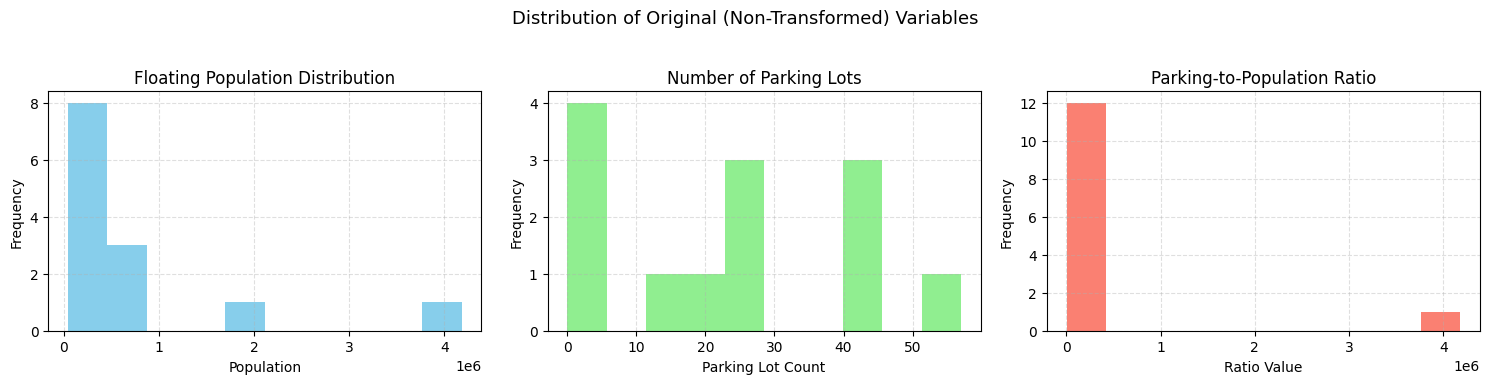

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Raw (non-log) histograms
axes[0].hist(df_merged['2021~2022년합계'], bins=10, color='skyblue')
axes[0].set_title('Floating Population Distribution')
axes[0].set_xlabel('Population')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, linestyle='--', alpha=0.4)

axes[1].hist(df_merged['주차장수'], bins=10, color='lightgreen')
axes[1].set_title('Number of Parking Lots')
axes[1].set_xlabel('Parking Lot Count')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, linestyle='--', alpha=0.4)

axes[2].hist(df_merged['유동인구대비 주차장비율'], bins=10, color='salmon')
axes[2].set_title('Parking-to-Population Ratio')
axes[2].set_xlabel('Ratio Value')
axes[2].set_ylabel('Frequency')
axes[2].grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Distribution of Original (Non-Transformed) Variables', fontsize=13)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


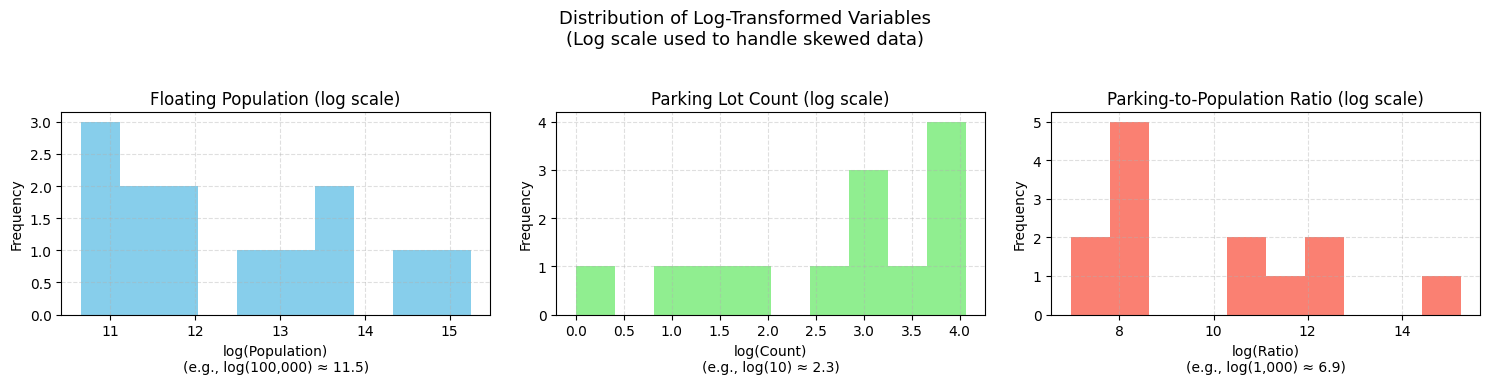

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Log transformation
df_merged['log_floating_population'] = np.log(df_merged['2021~2022년합계'] + 1)
df_merged['log_parking_count'] = np.log(df_merged['주차장수'] + 1)
df_merged['log_parking_ratio'] = np.log(df_merged['유동인구대비 주차장비율'] + 1)

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Floating population histogram
axes[0].hist(df_merged['log_floating_population'], bins=10, color='skyblue')
axes[0].set_title('Floating Population (log scale)')
axes[0].set_xlabel('log(Population)\n(e.g., log(100,000) ≈ 11.5)')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, linestyle='--', alpha=0.4)

# Parking lot count histogram
axes[1].hist(df_merged['log_parking_count'], bins=10, color='lightgreen')
axes[1].set_title('Parking Lot Count (log scale)')
axes[1].set_xlabel('log(Count)\n(e.g., log(10) ≈ 2.3)')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, linestyle='--', alpha=0.4)

# Parking ratio histogram
axes[2].hist(df_merged['log_parking_ratio'], bins=10, color='salmon')
axes[2].set_title('Parking-to-Population Ratio (log scale)')
axes[2].set_xlabel('log(Ratio)\n(e.g., log(1,000) ≈ 6.9)')
axes[2].set_ylabel('Frequency')
axes[2].grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Distribution of Log-Transformed Variables\n(Log scale used to handle skewed data)', fontsize=13)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [ ]:
import statsmodels.api as sm

X = df_merged[['log_유동인구', 'log_주차장비율']]
X = sm.add_constant(X)
y = df_merged['log_주차장수']

model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:               log_주차장수   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                     879.6
Date:                Sun, 15 Jun 2025   Prob (F-statistic):           5.77e-12
Time:                        06:27:08   Log-Likelihood:                 12.833
No. Observations:                  13   AIC:                            -19.67
Df Residuals:                      10   BIC:                            -17.97
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5495      0.340      1.616      0.1

/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=13 observations were given.
  return hypotest_fun_in(*args, **kwds)
